The following constitues a post-mortem analysis of the JHNSRE flight. The data is...certainly something.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FOR_POSTER = False
if FOR_POSTER:
    plt.style.use("poster.mplstyle")
else: plt.style.use("text.mplstyle")

df = pd.read_csv("data/binned.csv")

# Wrangle into minutes
df["Onboard Clock"] = pd.to_datetime(df["Onboard Clock"])
df["Time Offset"] = (df["Onboard Clock"] - df["Onboard Clock"].min()).dt.total_seconds() / 60

# Adjust based on known oddities with the binned data:
# 1. Binned data begins precisely 10 minutes after launch, within experimental uncertainty
# 2. Balloon is on the ground for the last >30 minutes of data collection.
LEAD_TIME_MIN = 10
GROUND_TIME_MIN = 30

df["Time Offset"] = df["Time Offset"] + LEAD_TIME_MIN
df = df[ (df["Time Offset"].max() - df["Time Offset"]) > GROUND_TIME_MIN ]

# Convenience and color..
adf = lambda df: df[ ~np.isnan(df["Altitude"]) ]
BLUE = "#2854c5"
RED = "#9e3d3d"
ORANGE = "#e66d22"
BLACK = "#000000"

# So you can have an idea:
df.iloc[:3]

,Onboard Clock,Latitude,Longitude,Altitude,CPM,Time Offset
0,2026-04-21 01:33:05.485094+00:00,40.46077,-78.38234,2940.0,1,10.0
1,2026-04-21 01:34:05.485094+00:00,40.45822,-78.37618,3270.0,2,11.0
2,2026-04-21 01:36:05.485094+00:00,40.45573,-78.36995,3600.0,2,13.0


Above is the rough format of our dataset for reference. Astute readers of our poster will notice a few things:

1. This data has been binned into one-minute windows prior to this analysis. Indeed, we are utilizing the `J6` pulse connector to interface the Geiger counter with our `stratosphere` daemon. `stratosphere` outputs one `JSON` object per pulse, which would be reasonable for the intended regime of operation ($10^3\,$ counts per minute, or CPM, at maximum). However, this was catastrophically inefficient in our Paschen and short-circuit regimes ($10^5\,$ CPM), producing a `pulses.jsonl` of size 2.6 *gigabytes*.

2. The Raspberry Pi Zero is reporting an earlier wall clock time than what we documented for our launch, by roughly three days. This is because the Pi's onboard clock does not update while the device is unpowered (i.e., there is no CMOS battery), and we didn't bother connecting the device to a wireless network at the launch site. This also ultimately proved catastrophic, as without `ssh` insight we could not distinguish that the camera had experienced a mechanical fault.

3. If you look further down in the dataset, you will notice that we do not have altitude measurements on descent. This is because (1.) we were busy chasing the balloon and (2.) the course taken by the balloon on descent deviated significantly from Cambridge's model. We are therefore not *as* confident in the descent altitude curve beyond approximate inference, and omit it from our analysis to achieve tighter uncertainty bands.

Speaking of uncertainty, here are the values we have justified on our poster:

In [2]:
# Via eyeball; Jay does not own calipers
Q1_LEAD_SPACING_M = 1e-3
Q1_LEAD_SPACING_UNCERTAINTY_M = 0.3e-3

# Via GPS updates and CUSF models
ALTITUDE_UNCERTAINTY_M = 150

# Square root approximation
df["CPM Uncertainty"] = np.sqrt(df["CPM"])

# Initial Data Appreciation

To interpolate altitude to atmospheric pressure, we utilize datasets derived from the [MIPAS](https://acp.copernicus.org/articles/8/2151/) on ESA's Envisat, accessed via the `joseki` Python library.

In [3]:
import joseki

JOSEKI_MODEL_ID = "mipas_2007-midlatitude_day"
atmosphere = joseki.make(
    identifier=JOSEKI_MODEL_ID,
    z= {"value": np.array(adf(df)["Altitude"]), "units": "m"}
)

a = np.array(atmosphere.p, copy=True)
a.resize((len(df), 1), refcheck=False)

df["Atmospheric Pressure (Pa)"] = a
df["Pressure Uncertainty (Pa)"] = df["Atmospheric Pressure (Pa)"] / df["Altitude"] * ALTITUDE_UNCERTAINTY_M

Now plot (and fight the color cycler).

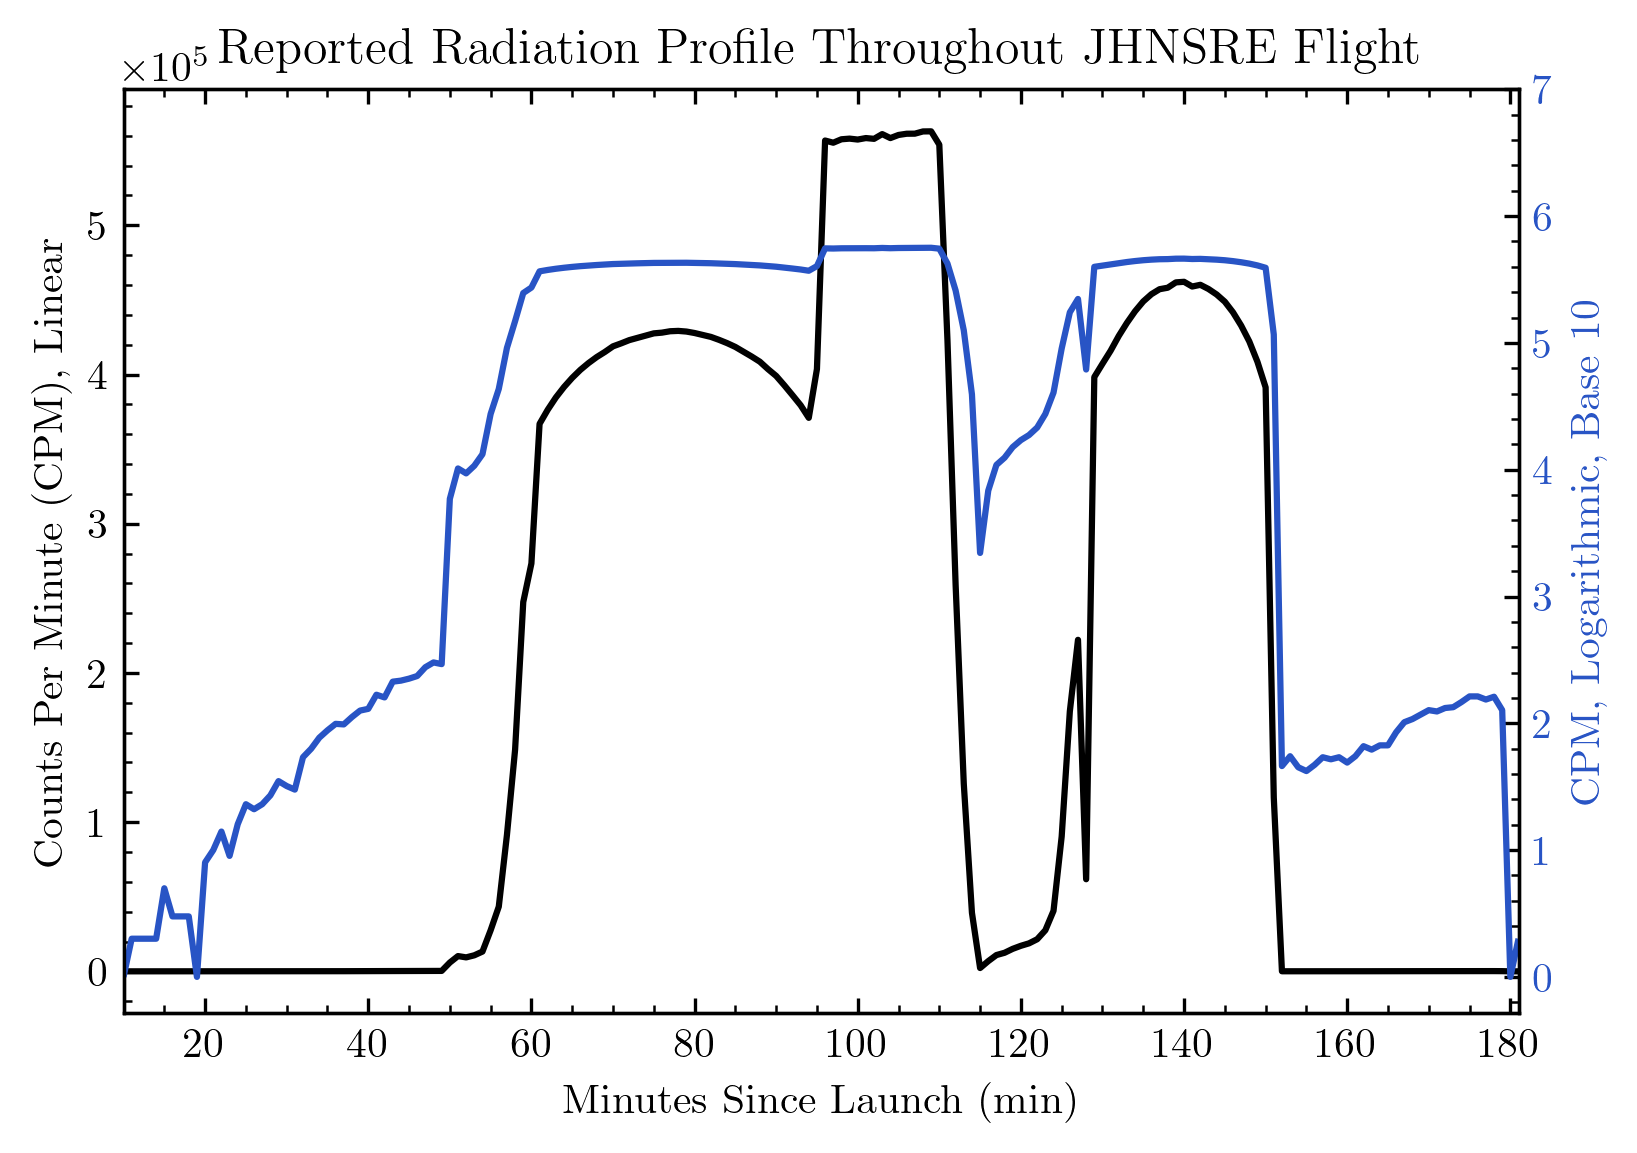

In [4]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot()
ax_log = ax.twinx()

ax.plot(df["Time Offset"], df["CPM"], color=BLACK)
ax.tick_params(axis="y", labelcolor=BLACK)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

ax_log.plot(df["Time Offset"], np.log10(df["CPM"]), color=BLUE)
ax_log.tick_params(axis="y", labelcolor=BLUE)
ax_log.set_ylim(ymax=7)

if not FOR_POSTER:
    plt.title("Reported Radiation Profile Throughout JHNSRE Flight")
    ax.set_xlabel("Minutes Since Launch (min)")
    ax.set_ylabel("Counts Per Minute (CPM), Linear", color=BLACK)
    ax_log.set_ylabel("CPM, Logarithmic, Base 10", color=BLUE)
else:
    plt.savefig("figures/altitude.png")
    
plt.show()

In this plot, all three regimes are clearly visible: the Pfotzer regime (most easily visualized on the log plot), the Paschen regime (on both ascent and descent: a nice U shape!), and the high altitude regime. Let's first plot the Pfotzer specifically.

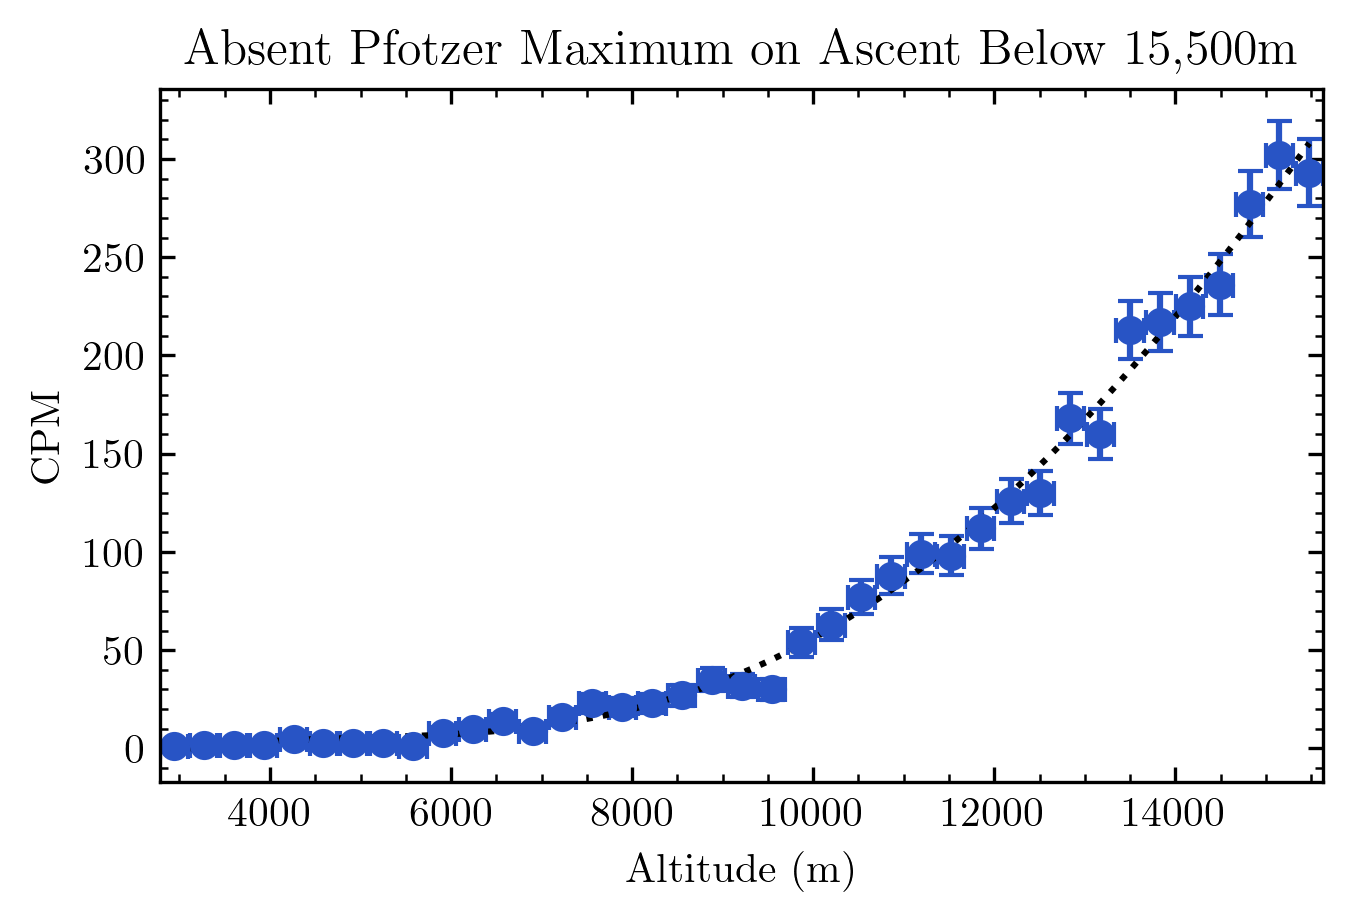

In [5]:
FEASIBLE_CPM_CEILING = 1e3
asc_pfotzer = df.loc[ (df["CPM"] < FEASIBLE_CPM_CEILING) & (~np.isnan(df["Altitude"]))]

fig = plt.figure(figsize=(5, 3))
ax = plt.subplot()

x = asc_pfotzer["Altitude"]
y = asc_pfotzer["CPM"]

plt.errorbar(
    x, y,
    xerr=ALTITUDE_UNCERTAINTY_M,
    yerr=asc_pfotzer["CPM Uncertainty"],
    fmt="o", color=BLUE
)

def aesthetic_curve_fit(x, y):
    # Not scientifically useful but gets a point across
    coeffs = np.polyfit(x, y, 4)
    model = np.poly1d(coeffs)

    x_smooth = np.linspace(x.min(), x.max(), 10000)
    return x_smooth, model(x_smooth)

fitx, fity = aesthetic_curve_fit(x, y)
plt.plot(fitx, fity, linestyle="dotted", color=BLACK)

if not FOR_POSTER:
    plt.title("Absent Pfotzer Maximum on Ascent Below 15,500m")
    ax.set_xlabel("Altitude (m)")
    ax.set_ylabel("CPM")
else:
    plt.savefig("figures/pfotzer.png")
    
plt.show()

We clearly see that we haven't found the Pfotzer maximum (before the instrument goes haywire above ~15km). Alas! While the final `x`-value on this graph *is* strictly lower than its predecessor, this is plausibly within random error per the square-root counting rule.

# Now for the fun part.

![ADDRESS ME](memes/addressme.jpeg)

We now consider the claimed Paschen phenomena. Having examined the spacing between high-voltage leads on the switching transistor, we consider the behavior of these leads on ascent.

Paschen's Law states that for parallel plates,

$$ V_B = \frac{Bpd}{\ln{(Apd)} - \ln{\left[\ln{\left(1 + \frac{1}{\gamma_{se}}\right)}\right]}} $$

...where $A$ and $B$ are characteristics of the medium, and $\gamma_{se}$ is the number of secondary electrons produced per incident positive ion. For air, $A = 112.5\,(\text{kPa} \cdot \text{cm})^{-1}$, $B = 2737.5\,\text{V} / (\text{kPa} \cdot \text{cm})^{-1}$, and $\gamma_{se}$ is often taken as $0.01$.

Note the units: this is a **pressure-distance product**.

Our Geiger tube measured "counts-per-minute", we interpret these counts as EMI events. We further reason that the periodicity of these EMI events - "minutes per count" - is a **monotonic** proxy for the breakdown voltage across the leads. Lesser time between counts implies a more violently discharging system, and therefore potentially a lower breakdown voltage.

As a first step, therefore, we plot inverse CPM in the region of interest and let the gap distance $d$ float. While we know $d$ to be roughly $1\,\text{mm}$, our first goal is to ascertain whether we have a Paschen-like shape at all. If we do, then we can dial in our value for $d$ and pursue a more rigorous result for the Paschen minimum.

/Users/jaytlang/Library/CloudStorage/OneDrive-JohnsHopkins/Classes/JHNSRE/env/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


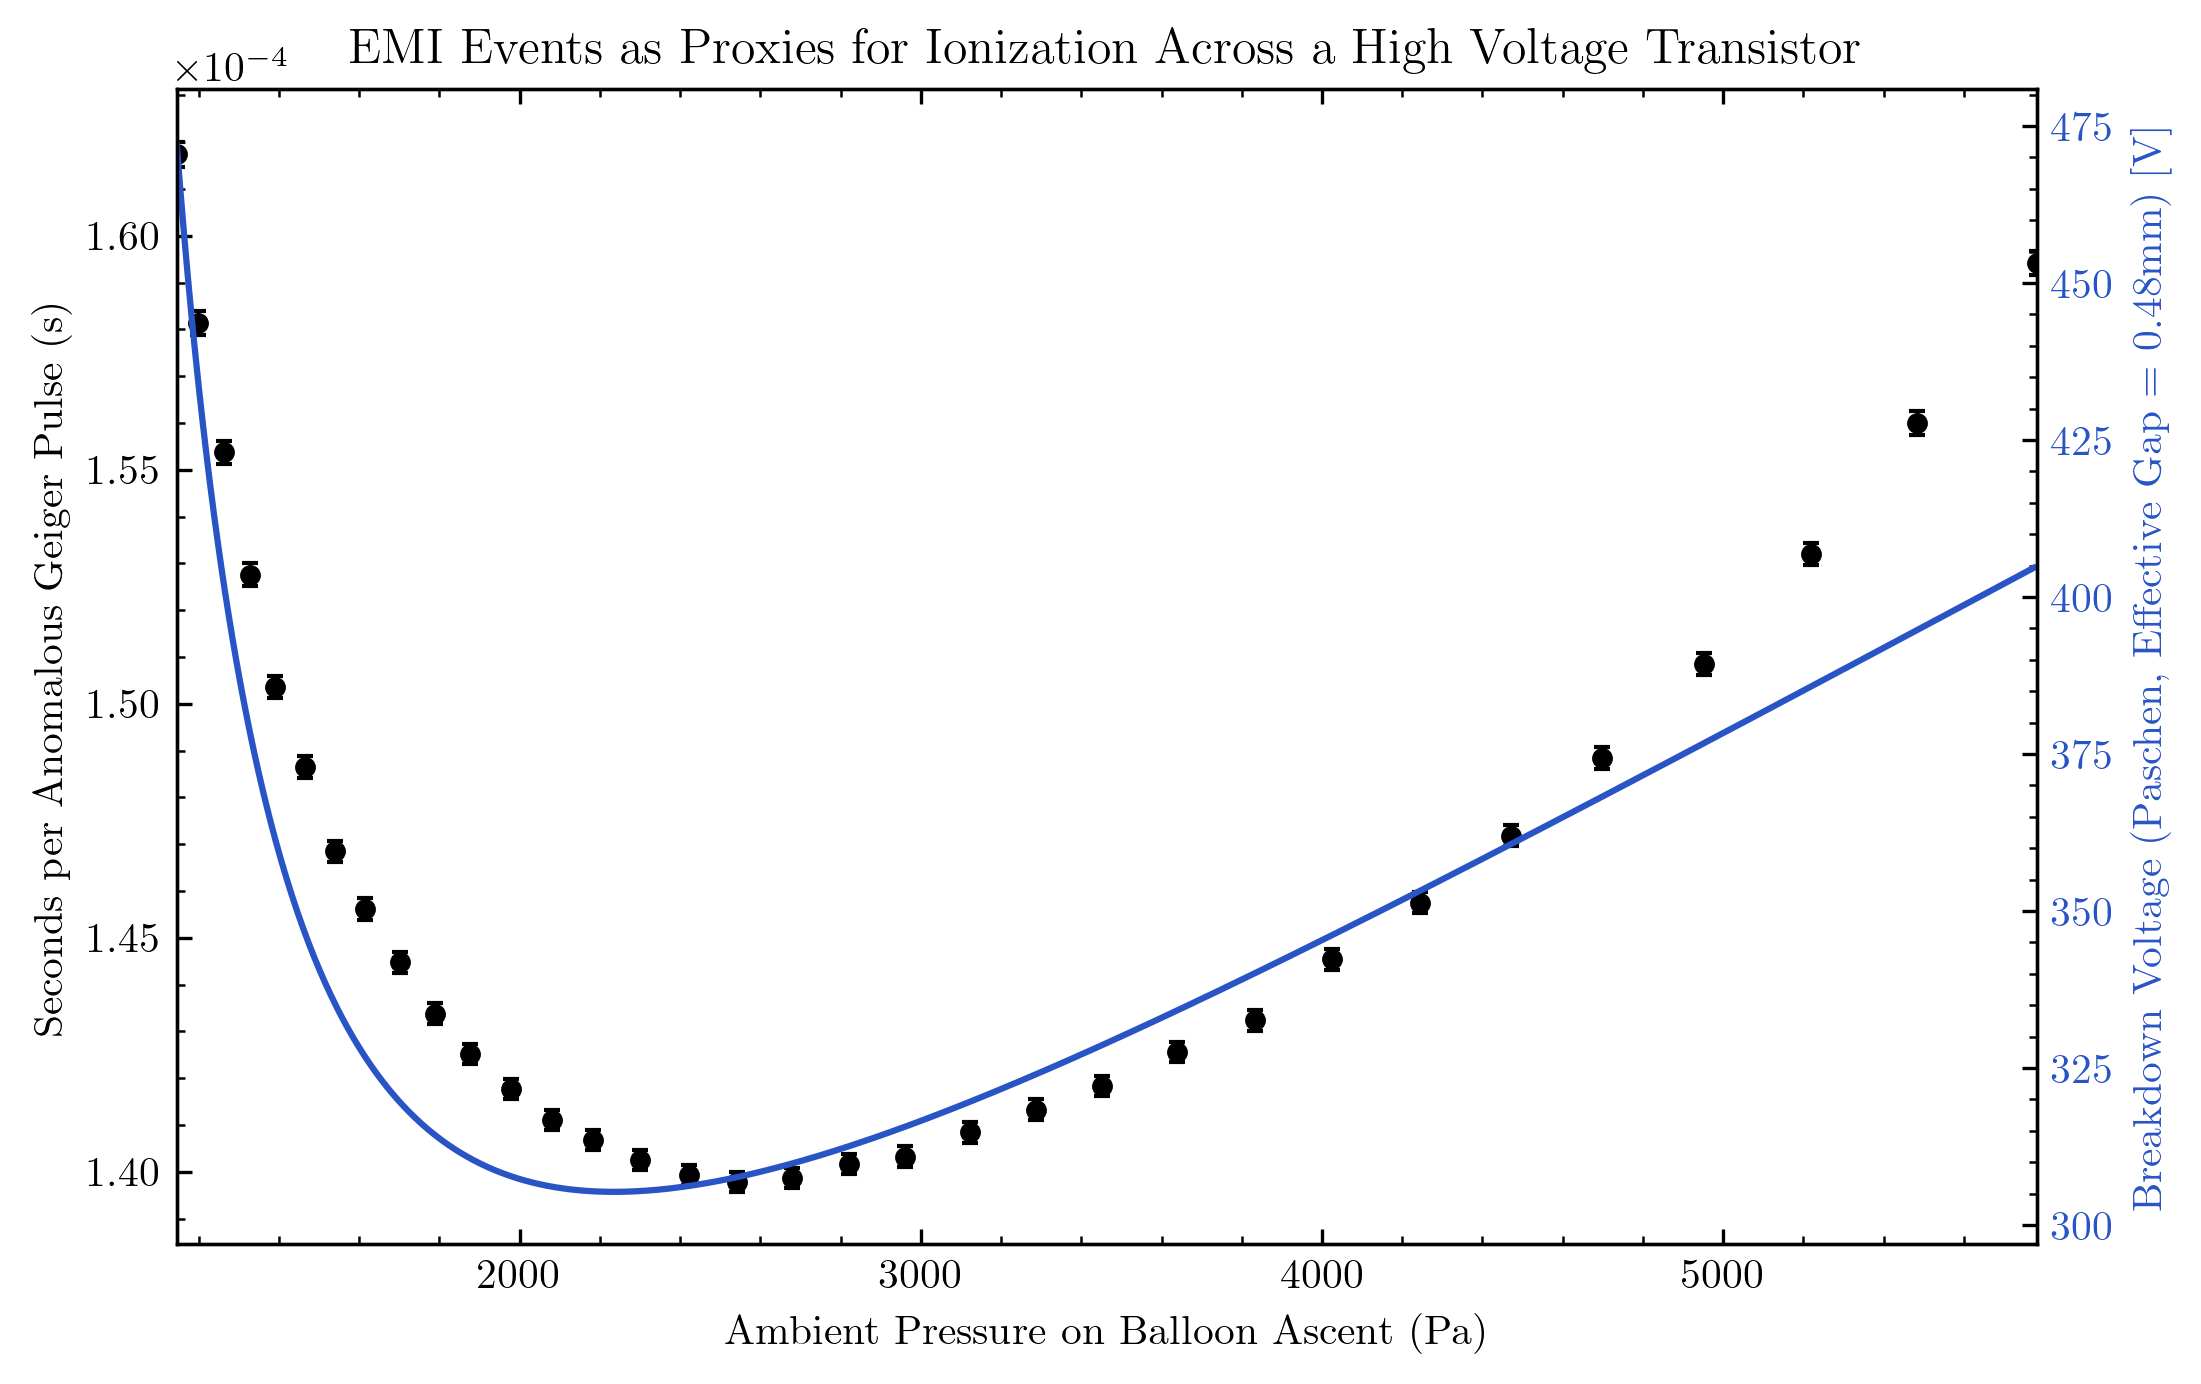

In [6]:
import scipy.optimize as opt

# Definitions
A = 11.25      # (Pa*m)^-1
B = 273.75     # V / (Pa*m)
GAMMA = 0.01   # Unitless
GAMMA_UNCERTAINTY = 0.008

def paschen_V(pressure, gap_distance):
    pd = pressure * gap_distance
    denom = np.log(A * pd) - np.log(np.log(1 + 1/GAMMA))
    return B * pd / denom

def model_spc(pressure, gap_distance, scale, offset):
    # The idea is that scale and offset absorb unknown proportionality
    # from the data. Similarly, we let d float. The idea is to just _try_
    # to see whether these shapes are even remotely 
    return scale * paschen_V(pressure, gap_distance) + offset

# Final data sanitization
PASCHEN_REGIME_MIN_ALTITUDE = 19500
PASCHEN_REGIME_MAX_ALTITUDE = 30500

adf = df[ ~np.isnan(df["Altitude"]) ]
u = adf[ (adf["Altitude"] >= PASCHEN_REGIME_MIN_ALTITUDE) & (adf["Altitude"] <= PASCHEN_REGIME_MAX_ALTITUDE) ]

x = u["Atmospheric Pressure (Pa)"]
y = u["SPC"] = 60 / u["CPM"]
dx = u["Pressure Uncertainty (Pa)"]
dy = 60.0 * u["CPM Uncertainty"].values / u["CPM"].values**2

# Now plot away...
fig, ax = plt.subplots(figsize=(8, 5))
ax_v = ax.twinx()

popt, _ = opt.curve_fit(model_spc, x, y, maxfev=2000)
fit, scale, offset= popt
ax.errorbar(x, y, yerr=dy,
            fmt="o", color=BLACK, ecolor=BLACK, markersize=4,
            elinewidth=0.8, capsize=2, zorder=3)
ax.tick_params(axis="y", labelcolor=BLACK)

p_smooth = np.linspace(x.min(), x.max(), 1000)
V_b_smooth = paschen_V(p_smooth, fit)
ax_v.plot(p_smooth, V_b_smooth, color=BLUE)
ax_v.tick_params(axis="y", labelcolor=BLUE)

ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

if not FOR_POSTER:
    ax.set_xlabel("Ambient Pressure on Balloon Ascent (Pa)")
    ax.set_ylabel("Seconds per Anomalous Geiger Pulse (s)", color=BLACK)
    ax_v.set_ylabel("Breakdown Voltage (Paschen, Effective Gap = 0.48mm) [V]", color=BLUE)
    ax.set_title(f"EMI Events as Proxies for Ionization Across a High Voltage Transistor", fontweight="bold")
else: plt.savefig("figures/paschen.png")

plt.show()

Looks phenomenal. We can now compute the experimental and theoretical Paschen minima, and compare the two.

In [7]:
import common
import math

def find_experimental_pd(u):
    exp_pressure = u.loc[ u["SPC"] == u["SPC"].min(), "Atmospheric Pressure (Pa)"].item()
    exp_uncertainty = u.loc[ u["SPC"] == u["SPC"].min(), "Pressure Uncertainty (Pa)"].item()
    
    pd = exp_pressure * Q1_LEAD_SPACING_M
    pressure_contribution = Q1_LEAD_SPACING_M * exp_uncertainty
    gap_contribution = Q1_LEAD_SPACING_UNCERTAINTY_M * exp_pressure

    return pd, math.sqrt(pressure_contribution**2 + gap_contribution**2)

pd_exp, dpd_exp = find_experimental_pd(u)
print(f"Experimental Paschen minimum: {common.sf(pd_exp, dpd_exp)} (Pa m)")

Experimental Paschen minimum: 2.5 ± 0.8 (Pa m)


In [8]:
def find_theoretical_pd(u):
    pd = math.e * math.log(1 + 1/GAMMA) / A
    dpd = math.e * GAMMA_UNCERTAINTY / (A * GAMMA * (GAMMA + 1))

    return pd, dpd

pd_thr, dpd_thr = find_theoretical_pd(u)
print(f"Theoretical Paschen minimum: {common.sf(pd_thr, dpd_thr)} (Pa m)")
print(f"\t=> Discrepancy: t = {common.discrepancy(pd_thr, dpd_thr, pd_exp, dpd_exp)}")

Theoretical Paschen minimum: 1.12 ± 0.19 (Pa m)
	=> Discrepancy: t = 1.81
